In [138]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns




In [139]:
df = pd.read_csv("/Users/v/Data Science Projects/time-series-project/data/original/retail_sales_mock_data.csv")


what needs to be done for ML models:

* cleaning of the features to ensure integrity
* feature engieering to create new aggregate features (rolling mean etc)
* creating lag features to allow for regression models to be able to learn and model 'time'



check data integrity 

the purpose of EDA is to:

* Identify structure

* detect anomalies

* validate assumptions

to later inform decisions for:

* data preprocessing

* feature engineering

* model selection

* evaluation design



# EDA in chronological order

# Step 1: check data integrity

are there any:

* missing values?
* duplicates?

what are the column types?

Time index consistency? (Monotonic Ordering)  




In [140]:
#are there any missing values?
#are the types correct for the columns?
print(df.info())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          48 non-null     str  
 1   SalesAmount   48 non-null     int64
 2   Promotion     48 non-null     int64
 3   HolidayMonth  48 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.6 KB
None
0


there are no missing values and no duplicates either in the dataframe

However the type of 'Date' column should not be a str but instead be a Datetime as well as the index of the df

In [141]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index(df['Date'])
print(type(df.index))
print(df.index.is_monotonic_increasing)
print(df.index.freq)
df = df.asfreq('MS')
print(df.index.freq)


<class 'pandas.DatetimeIndex'>
True
None
<MonthBegin>


the index of the dataframe is now date as is of the datetime type 

the df index frequency was not inferred by pandas so i have enforced it for stability in the pipeline


# Step 2: Missing Value Analysis

What is done:
* Visualize missing patterns
* Check randomness of missingness

Common tools:
* Heatmaps
* Time gap plots

but there are no missing values so i will skip this step

# Step 3. Decomposition

decompose the dataframe into its 3 components of Trend, Seasonality and Residuals

The goal of time-series decomposition is to understand the structural components of the signal so that modelling and preprocessing decisions are better informed.

first we will visualise the target variable we are aiming to forecast against time to decide if we should use an additive or multiplicative model

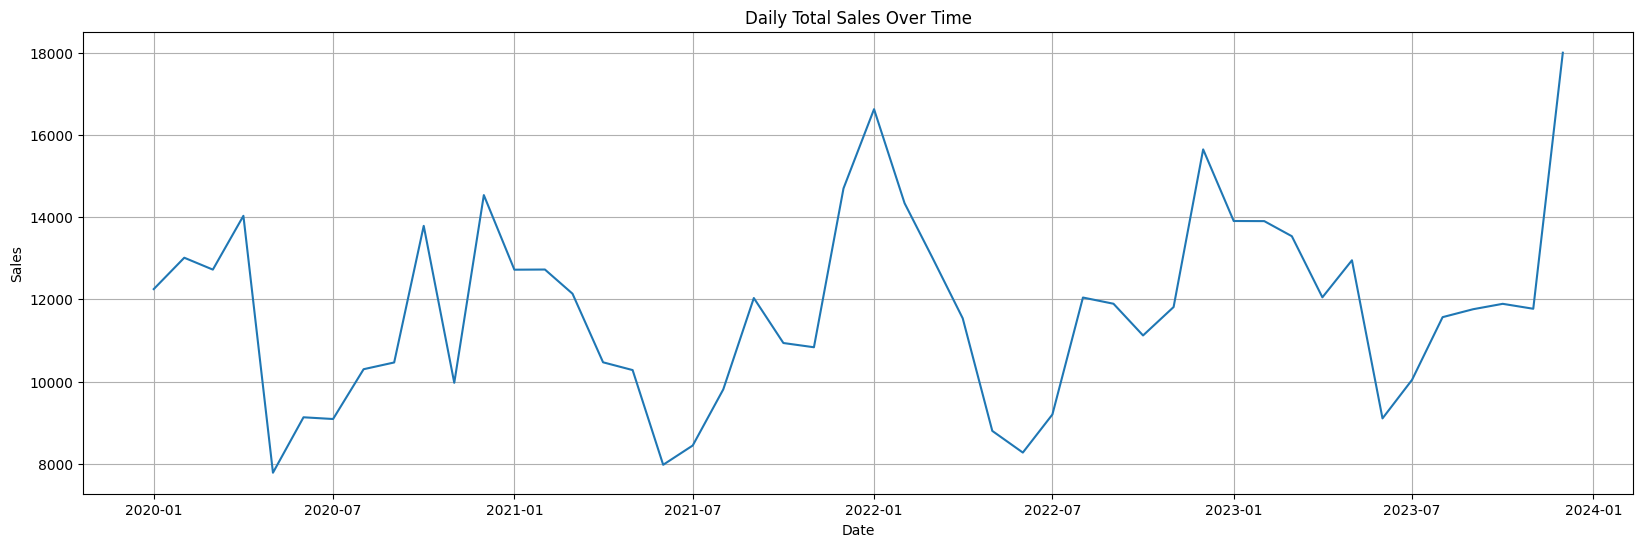

In [142]:
plt.figure(figsize=(20,6))
plt.plot(df.index, df['SalesAmount'])
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

from this graph as can observe a clear repeating structure, a.k.a, seasonality.

we can also obersve an increasing trend although it is weak  

it is not clear if the data models as multiplicative or additive so we will inspect both

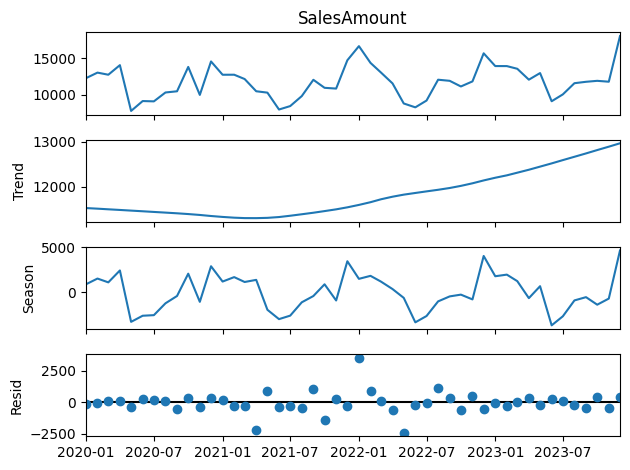

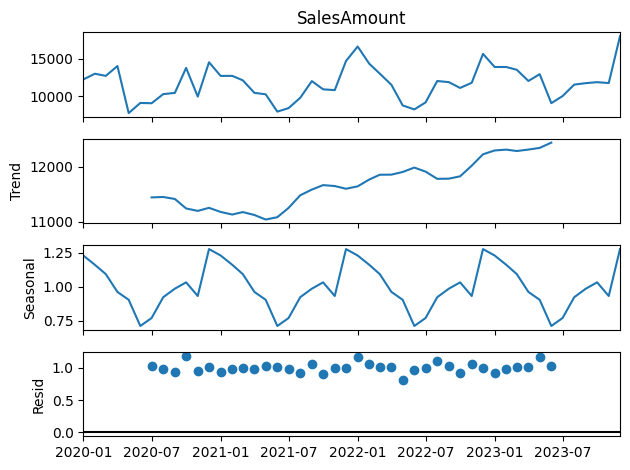

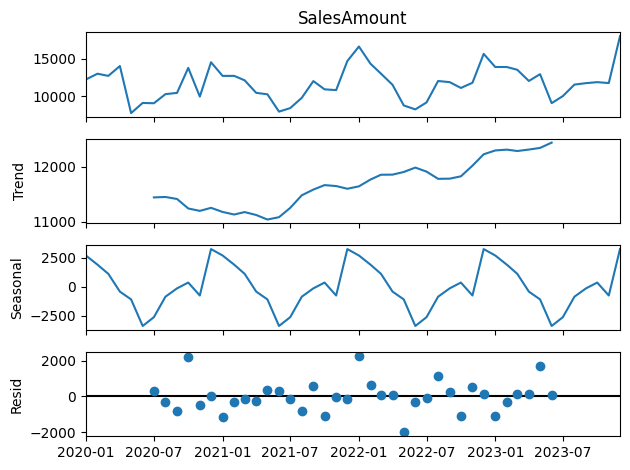

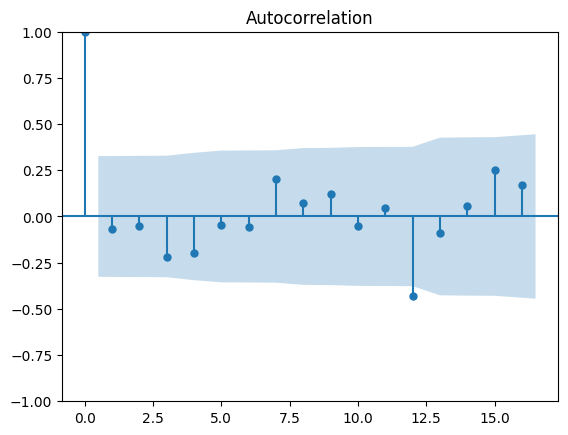

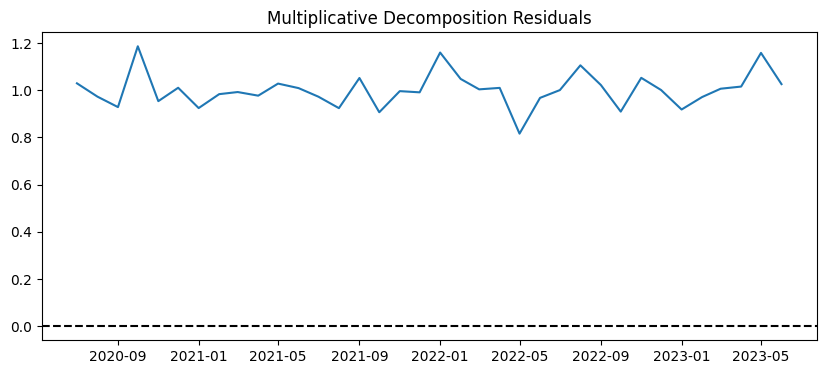

stl resid std:  833.6828332612928
stl resid mean:  -25.92285736611412
 resid df_decomp_mul mean:  1.0008383731246566
 resid df_decomp_mul std:  0.07223781263065451
 resid df_decomp_add mean:  12.016203703704049
 resid df_decomp_add std:  859.2359154939895


In [143]:
df_decomp_mul = seasonal_decompose(df['SalesAmount'],model='multiplicative')
df_decomp_add = seasonal_decompose(df['SalesAmount'],model='additive')

stl = STL(df['SalesAmount'], period=12, seasonal=13, robust=True)
result = stl.fit()

result.plot()
df_decomp_mul.plot()
df_decomp_add.plot()

resid_mul = df_decomp_mul.resid.dropna()
plot_acf(resid_mul)
plt.figure(figsize=(10,4))
plt.plot(df_decomp_mul.resid)
plt.title("Multiplicative Decomposition Residuals")
plt.axhline(0, color='black', linestyle='--')

plt.show()
print('stl resid std: ',np.std(result.resid))
print('stl resid mean: ',np.mean(result.resid))
print(' resid df_decomp_mul mean: ',np.mean(df_decomp_mul.resid))
print(' resid df_decomp_mul std: ',np.std(df_decomp_mul.resid))

print(' resid df_decomp_add mean: ',np.mean(df_decomp_add.resid))
print(' resid df_decomp_add std: ',np.std(df_decomp_add.resid))



As hypothesised: We observe clear seasonality and a weak increasing trend

From this we can see that the residuals for the multiplicative model have a smaller variance and a smaller mean value. Thus, the residuals are roughly homoscedastic and therfore, the multiplicative model better explains the structure.

# Step 4. Stationarity Testing

The purpose of stationarity testing is to determine if the data has a constant mean and no variance as most statistical models assume this. This is done through statistical tests such as the Augmented Dickey-Fuller test. 

If it is not stationary then this can be done through differencing and log/box-cox transformation.


In [144]:
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(df['SalesAmount'])

ADF Statistic: -4.514183597733958
P-Value: 0.00018535586430261367
Critical Values:
	1%: -3.60
	5%: -2.93
	10%: -2.60


From these results we can with atleast a 99% certainty say that the target variable is stationary 

In [145]:
df_copy = df.copy()


# Step 5: ACF & PACF Statistics


The purpose of testing/plotting autocorrelation and partial autocorrelation is to observe the lags that will provide our model with useful information in order to better inform the modelling decisions

ACF → tells you where temporal memory exists

ACF = “Is there correlation with the past?”

--------------------------------------------------------------

PACF → tells you where direct temporal influence is strongest

PACF = “Which past point directly matters?”

PACF helps identify lags that have direct residual predictive power after removing intermediate lag effects.

ACF answers:

How much does y_{t-k} indirectly and directly influence y_t?

PACF answers:

What is the correlation between y_t and y_{t-k} after removing influence of lags 1…k-1?

for non seasonal order(p,q), observe the cut off 

for seasonal order (P,Q), observe the recurring spikes

# Key insight

If my data is stationary according to adf tests, I should plot the ACF of the residuals of the decomposition. If i observe lag spikes outside of the blue region at key lags that suggest seasonality then I should do seasonal differencing on the data.

After doing the seasonal differencing i plot the acf and pacf of the seasonally-differenced data to observe where lags cut off and where lags spike at seasonal intervals? in order to infer (p,q) and (P,Q) respectively


ADF test

    ↓

If stationary → d = 0

    ↓

Check seasonal ACF structure

    ↓

If seasonal spike exists → D = 1

    ↓

Apply seasonal differencing

    ↓

Plot ACF/PACF of transformed series

    ↓

Estimate p,q,P,Q candidates

    ↓

Validate using CV forecast error

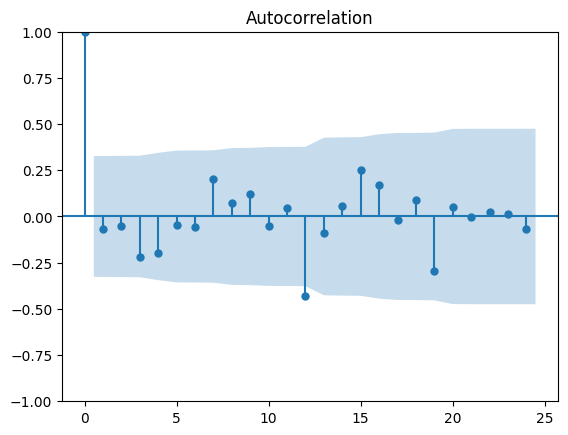

In [146]:
df_decomp_mul = seasonal_decompose(df['SalesAmount'],model='multiplicative')
df_mul_resid = df_decomp_mul.resid.dropna()

plot_acf(df_mul_resid, lags=24)
plt.show()

There is a spike outside of the confidence region at lag 12, this tells us that that even though the series is stationary, seasonal structure/correlation remains.

As such, we must seasonally difference the data before plotting ACF and PACF for diagnosing AR and MA, and make a note of setting D in a range of 0,1 in the SARIMA modelling

# Step 5.1: Seasonal Differencing 

ADF Statistic: -4.514183597733958
P-Value: 0.00018535586430261367
Critical Values:
	1%: -3.60
	5%: -2.93
	10%: -2.60
ADF Statistic: -3.626089214905155
P-Value: 0.005281405417340895
Critical Values:
	1%: -3.65
	5%: -2.96
	10%: -2.62


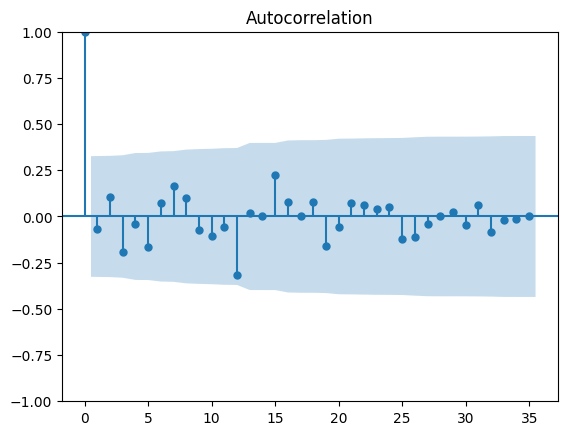

In [147]:
adf_test(df['SalesAmount'])
df['seasonal_diff'] = df['SalesAmount'].diff(12)
#df['seasonal_diff'] = df['seasonal_diff'].dropna()
adf_test(df['seasonal_diff'])

plot_acf(df['seasonal_diff'].dropna(), lags=35)
plt.show()

it does not matter that .diff(12).dropna() truncates the first 12 observations, because the lag-12 spike represents global seasonal dependence in the process rather than dependence restricted to specific sample pairs.

# Step 5.2: ACF and PACF of stationary data


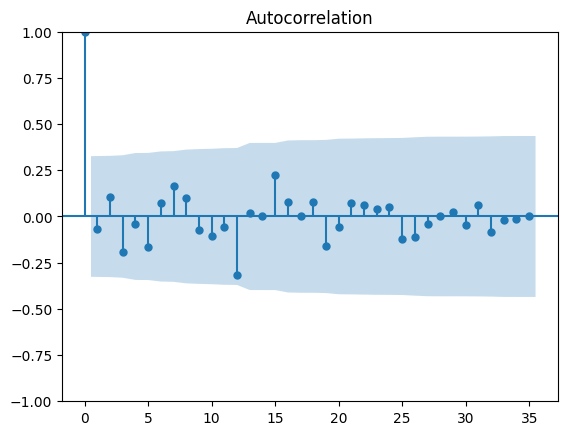

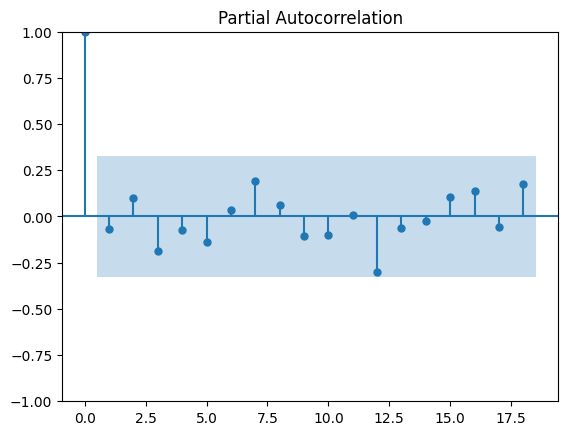

In [148]:
plot3 = plot_acf(df['seasonal_diff'].dropna(), lags=35)
plot4 = plot_pacf(df['seasonal_diff'].dropna(), lags=18)
plt.show()

From the ACF and PACF plots we can observe the lags that would provide meaningful information to models

for sarima:

* PACF → Determines AR(autoregressive) Order (p,P) 
* ACF → Determines MA Order (q,Q)






# Step 5.3: SARIMA-hyperparameter insights

The data was already stationary, d = 0

The cut off is immediate for both ACF and PACF, thus p,q ∈ {0,1}

The data was seasonally-differenced, thus D = 1

There is no strong evidence requiring seasonal AR/MA as there are no seasonal spikes outside of confidence region for both ACF and PACF, thus P,Q ∈ {0,1}

The data is monthly, thus s = 12

# 5.4: ML models insights 

ML models can use acf and pacf plots of the original data in order to indentify the lags with the most information in order guide feature engineering

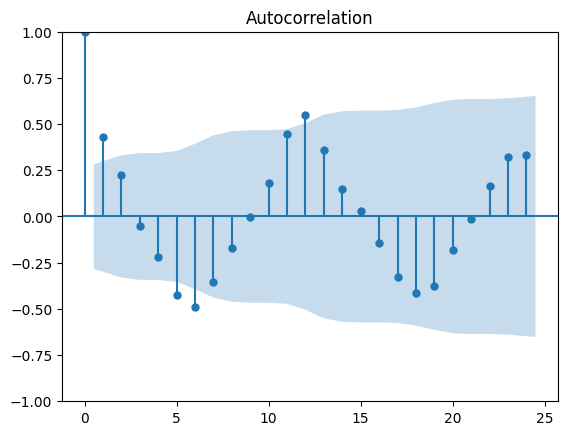

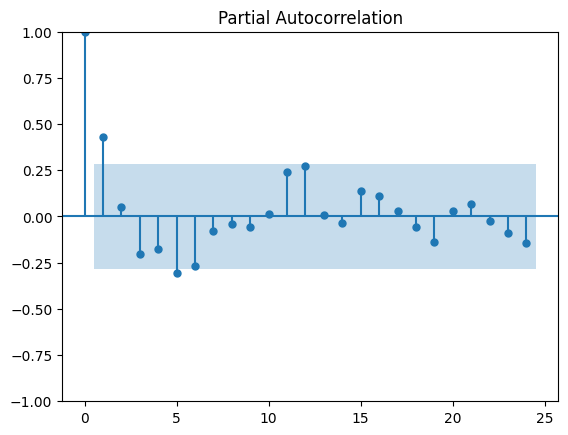

In [149]:
ml_df = df_copy.copy()
plot_acf(ml_df['SalesAmount'],lags=24)
plot_pacf(ml_df['SalesAmount'],lags=24)
plt.show()

From this we can observe that lags 1, 5, 6 & 12 would provide the most information

for ML models:

* Lag feature set = {lags with strong ACF signal} ∪ {lags with strong PACF signal}

# Step 5.5: ML model-hyperparameter insights

The feature engineering should be done such that lags and rolling means of these lengths should be encoded into the dataset

# Step 6. Outlier Detection


Outliers can:

* Distort parameter estimation
* Create unstable forecasts

Methods:

* Boxplot inspection
* Z-score
* Residual analysis



<Axes: xlabel='Date', ylabel='SalesAmount'>

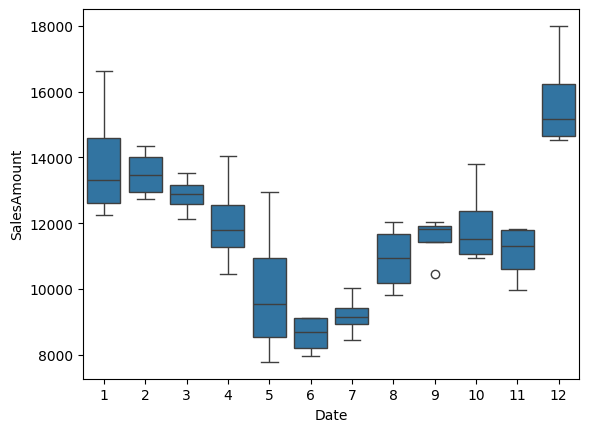

In [150]:
sns.boxplot(x=df.index.month, y=df["SalesAmount"], data=df)

In [151]:
month_data = df[df.index.month == 9]['SalesAmount']

print(month_data.sort_values(ascending=False).head(20))
print(df[df.index.month == 9])


Date
2021-09-01    12031
2022-09-01    11892
2023-09-01    11759
2020-09-01    10464
Name: SalesAmount, dtype: int64
                 Date  SalesAmount  Promotion  HolidayMonth  seasonal_diff
Date                                                                      
2020-09-01 2020-09-01        10464          0             0            NaN
2021-09-01 2021-09-01        12031          0             0         1567.0
2022-09-01 2022-09-01        11892          0             0         -139.0
2023-09-01 2023-09-01        11759          0             0         -133.0


There is nothing to indicate this monthly is truely an outlier in any specific capacity, people just bought less this month

# Step 7: Pipeline Decision Finalisation


After EDA you decide:

Model family

	•	Classical statistical → SARIMA

	•	Machine learning → GBM, NN

⸻

Validation strategy

For time-series:

👉 Walk-forward validation

👉 Recursive forecasting evaluation

MAE to be used to avoid error propagation of recursive forecasting

------------
steps SARIMA:

ingest

clean

test/train split

create hyperparameter grid

do cv

train final model with best params

evaluate best model on testing data

-----------------------------
steps ML model:

ingest

clean

feature engineering (rolling features with .shift(1))

test/train split 

create hyperparameter grid

do cv 

train final model on training data

evaluate best model on testing data

--------------------------